# **Distance matrix**

Derivation of distance matrix in terms of layovers – edges are weighted $1$.

In [1]:
import pandas as pd
import numpy as np
from scipy.sparse.csgraph import shortest_path
from scipy.sparse import csr_matrix
from scipy.stats import chisquare
import powerlaw

import seaborn as sns
import matplotlib.pyplot as plt

from math import comb

In [2]:
edges = pd.read_csv("../data/edges.csv")[["# source", " target", " distance"]].drop_duplicates()

nodes = pd.read_csv("../data/nodes.csv")[[" id", " name", " city", " country"]]
nodes[" id"] = np.arange(0, 3214)

In [3]:
source_airport = np.array(edges["# source"])
destination_airport = np.array(edges[" target"])

layovers = np.ones(len(source_airport)) # len(nodes) flights per 1 (one flight)

G = csr_matrix((layovers, (source_airport, destination_airport)), shape=(3214, 3214))

layover_matrix, pred_matrix = shortest_path(csgraph=G, directed=True, method="auto", return_predecessors=True)
layover_matrix[np.where(layover_matrix > 0)] -= 1

# Unreachability

In [4]:
print(f"{100*(np.isinf(layover_matrix).sum() / 3214**2):.2f} % of pairs are unreachable")

2.87 % of pairs are unreachable


# Layovers

In [5]:
print(f"{ np.mean(layover_matrix, where=( ~np.isinf(layover_matrix) & (layover_matrix != 0) ))} priemerný počet lay-overs")

2.9969801292746436 priemerný počet lay-overs


# Layover matrix

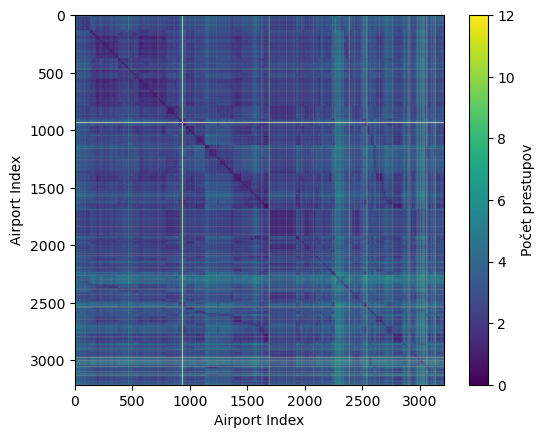

In [6]:
plt.imshow(layover_matrix)

plt.xlabel("Airport Index")
plt.ylabel("Airport Index")

cbar = plt.colorbar()
cbar.set_label("Počet prestupov")

plt.show()

# Unreachable duos

In [9]:
infs = np.where(np.isinf(layover_matrix))
with open("unreachable_duos.txt", "a") as file:
    for i in range(len(infs[0])):
        FROM = infs[0][i]
        TO = infs[1][i]

        file.write(f"{nodes[nodes[" id"] == FROM][" name"].values[0]} – {nodes[nodes[" id"] == TO][" name"].values[0]}\n")


# Priamo dosiahnuteľné letiská

In [7]:
100*(np.sum(layover_matrix == 0) - 3214) / 3214**2

np.float64(0.3572771427431868)

# Distribution of layovers

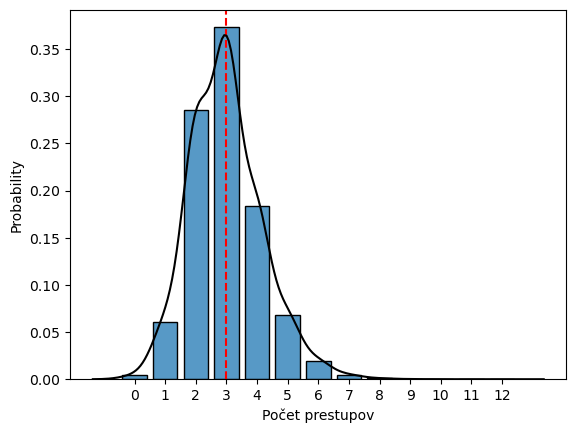

In [8]:
layover_values = layover_matrix.flatten()
layover_values = layover_values[np.isfinite(layover_values) & (layover_values >= 0)]

sns.histplot(layover_values, discrete=True, shrink=0.8, stat="probability")
plt.xticks(range(int(layover_values.max()) + 1))
plt.xlabel("Počet prestupov")

plt.axvline(np.mean(layover_values), linestyle="dashed", color="red")

sns.kdeplot(data=layover_values, bw_adjust=10, color="black")

plt.show()

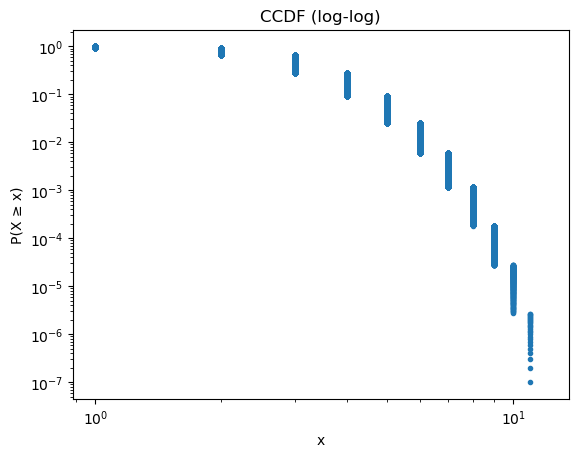

In [ ]:
# zoradenie
x = np.sort(layover_values)
n = len(x)

# CCDF: P(X >= x) -> Ukazuje sa, že power law nie je zrovna kandidát :(
ccdf = 1.0 - np.arange(1, n+1) / n

plt.figure()
plt.loglog(x, ccdf, marker='.', linestyle='none')
plt.xlabel('x')
plt.ylabel('P(X ≥ x)')
plt.title('CCDF (log-log)')
plt.show()

In [ ]:
plt.scatter(layover_values)
plt.show()

TypeError: scatter() missing 1 required positional argument: 'y'

# Diameter - maximum layover

In [26]:
def get_actual_route(predecessors, start_node, end_node):
    path = []
    curr = end_node
    
    # -9999 is the default "no path" value in SciPy's predecessor matrix
    if predecessors[start_node, curr] == -9999 and start_node != end_node:
        return "No path exists"
        
    while curr != -9999:
        path.append(curr)
        if curr == start_node:
            break
        curr = predecessors[start_node, curr]
        
    return path[::-1] # Reverse it to get start -> end

In [27]:
MAXIMUM = np.max(layover_matrix[np.isfinite(layover_matrix)])

#np.where(layover_matrix == 12) # 2317, 465

#print(nodes[nodes[" id"] == 2317])
#print(nodes[nodes[" id"] == 465])

# Fajný tripík :)
route = get_actual_route(pred_matrix, 2317, 465)

for i in route:
    print(nodes[nodes[" id"] == i][[" city", " country"]].values)



[['Peawanuck' 'Canada']]
[['Attawapiskat' 'Canada']]
[['Kashechewan' 'Canada']]
[['Fort Albany' 'Canada']]
[['Moosonee' 'Canada']]
[['Timmins' 'Canada']]
[['Toronto' 'Canada']]
[['Istanbul' 'Turkey']]
[['Kinshasa' 'Congo (Kinshasa)']]
[['Kisangani' 'Congo (Kinshasa)']]
[['Goma' 'Congo (Kinshasa)']]
[['Beni' 'Congo (Kinshasa)']]
[['Bunia' 'Congo (Kinshasa)']]
[['Isiro' 'Congo (Kinshasa)']]


In [33]:
trip = []
for i in range(len(route) - 1):
    trip.append((route[i], route[i+1]))

In [34]:
edges

,# source,target,distance
0,0,2,124.520121
1,0,3,157.150822
2,0,1,106.747399
3,0,4,424.726096
5,1,0,106.747399
...,...,...,...
66764,3211,1655,731.349310
66765,3211,2840,375.021414
66766,3211,2767,1217.384762
66769,3212,1675,425.533589


In [43]:
distances = []
for i in trip:
    distances.append(edges[(edges["# source"] == i[0]) & (edges[" target"] == i[1])][" distance"].values)

np.sum(distances)

np.float64(17255.573373175812)